# Load libraries and data

In [219]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import scipy as sp
import os
import requests 
from urllib.parse import urlencode
import time
import ast

In [17]:
!pip install requests

In [37]:
# -----------------------------
# 1️⃣ TMDB API Setup
# -----------------------------
API_KEY = "<<remove since notebook is public>"  
NETFLIX_PROVIDER_ID = 8    # TMDB provider ID for Netflix

# Regions to include (Southeast Asia, AU/NZ, Taiwan/HK)
regions = ["SG","MY","ID","PH","TH","VN","BN","AU","NZ","TW","HK"]

In [143]:
# -----------------------------
# 2️⃣ Fetch main movie/TV data based on netflix as provided and of region
# -----------------------------


def fetch_tmdb_region(content_type="movie", region="SG", page=1):
    base_url = f"https://api.themoviedb.org/3/discover/{content_type}"

    sort_field = "release_date" if content_type == "movie" else "first_air_date"

    params = {
        "api_key": API_KEY,
        "with_watch_providers": str(NETFLIX_PROVIDER_ID),
        "watch_region": region, 
        "sort_by": f"{sort_field}.desc",
        "page": page
    }

    # This is the literal URL TMDB receives
    full_url = f"{base_url}?{urlencode(params)}"
    #print(full_url)  #for debugging purpose

    response = requests.get(base_url, params=params, timeout=20)
    response.raise_for_status()
    return response.json()



In [131]:
# -----------------------------
# 2️⃣ loops through all the region to pass back to fetch_tmdb_region
# -----------------------------
def fetch_tmdb_all_regions(content_type="movie", page=1):
    all_results = {}

    for region in regions:  #takes from regions list
        data = fetch_tmdb_region(content_type, region, page)

         # If this region has no results, just skip it
        if not data or not data.get("results"):
            continue

        for item in data.get("results", []):
            tmdb_id = item["id"]

            if tmdb_id not in all_results:
                all_results[tmdb_id] = dict(item)
                all_results[tmdb_id]["available_regions"] = []

            all_results[tmdb_id]["available_regions"].append(region)

    return list(all_results.values())


In [66]:
# 3️⃣ Get genre mappings
# -----------------------------
def get_genres(content_type="movie"):
    url = f"https://api.themoviedb.org/3/genre/{content_type}/list"
    params = {"api_key": API_KEY}
    response = requests.get(url, params=params).json()
    return {g['id']: g['name'] for g in response.get('genres', [])}

movie_genres = get_genres("movie")
tv_genres = get_genres("tv")

In [144]:
# -----------------------------
# 5️⃣ Build dataset with deduplication
# -----------------------------
def build_dataset(content_type="movie", max_pages=None):
    all_data = []
    seen_ids = set()
    page = 1

    while True:
        items = fetch_tmdb_all_regions(content_type, page)

        if not items:
            break

        for item in items:
            tmdb_id = item['id']
            
            if tmdb_id in seen_ids:
                continue

            seen_ids.add(tmdb_id)

            genres = [movie_genres.get(g, tv_genres.get(g, g)) for g in item.get('genre_ids', [])]

            # Check Netflix availability in selected regions
          #  on_netflix = check_netflix_availability(tmdb_id, content_type)

            all_data.append({
                "id": tmdb_id,
                "type": content_type,
                "title": item.get("title") or item.get("name"),
                "release_date": item.get("release_date") or item.get("first_air_date"),
                "date_added_estimated": item.get("release_date") or item.get("first_air_date"),
                "genres": ", ".join(genres),
                "popularity": item.get("popularity"),
                "vote_average": item.get("vote_average"),
                "vote_count": item.get("vote_count"),
                "regions": item.get("available_regions")
               # "country": item.get("country"),
               # "on_netflix": on_netflix
            })

        print(f"Fetched page {page} of {content_type}s...")
        page += 1
        if max_pages and page > max_pages:
            break
   
        time.sleep(0.25)  # avoid API rate limits

    return all_data


In [173]:
# -----------------------------
# 6️⃣ Fetch movies and TV shows
# -----------------------------
print("Fetching Netflix movies in selected regions...")
movies = build_dataset("movie", max_pages=50)  # limit for testing

print("Fetching Netflix TV shows in selected regions...")
tv_shows = build_dataset("tv", max_pages=50)


Fetching Netflix movies in selected regions...
Fetched page 1 of movies...
Fetched page 2 of movies...
Fetched page 3 of movies...
Fetched page 4 of movies...
Fetched page 5 of movies...
Fetched page 6 of movies...
Fetched page 7 of movies...
Fetched page 8 of movies...
Fetched page 9 of movies...
Fetched page 10 of movies...
Fetched page 11 of movies...
Fetched page 12 of movies...
Fetched page 13 of movies...
Fetched page 14 of movies...
Fetched page 15 of movies...
Fetched page 16 of movies...
Fetched page 17 of movies...
Fetched page 18 of movies...
Fetched page 19 of movies...
Fetched page 20 of movies...
Fetched page 21 of movies...
Fetched page 22 of movies...
Fetched page 23 of movies...
Fetched page 24 of movies...
Fetched page 25 of movies...
Fetched page 26 of movies...
Fetched page 27 of movies...
Fetched page 28 of movies...
Fetched page 29 of movies...
Fetched page 30 of movies...
Fetched page 31 of movies...
Fetched page 32 of movies...
Fetched page 33 of movies...
Fetch

In [180]:
tv_shows

[{'id': 308558,
  'type': 'tv',
  'title': 'Paparazzi King',
  'release_date': '2026-01-09',
  'date_added_estimated': '2026-01-09',
  'genres': 'Documentary',
  'popularity': 7.0432,
  'vote_average': 0.0,
  'vote_count': 0,
  'regions': ['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW', 'HK']},
 {'id': 259731,
  'type': 'tv',
  'title': 'HIS & HERS',
  'release_date': '2026-01-08',
  'date_added_estimated': '2026-01-08',
  'genres': 'Mystery, Crime, Drama',
  'popularity': 103.56,
  'vote_average': 5.375,
  'vote_count': 48,
  'regions': ['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW', 'HK']},
 {'id': 263330,
  'type': 'tv',
  'title': 'SHIBOYUGI: Playing Death Games to Put Food on the Table',
  'release_date': '2026-01-07',
  'date_added_estimated': '2026-01-07',
  'genres': 'Animation, Action & Adventure',
  'popularity': 20.3377,
  'vote_average': 7.4,
  'vote_count': 6,
  'regions': ['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW', 'HK']},
 {'id': 310070,
  'type': 'tv',
  'title': 

In [181]:
# -----------------------------
# 7️⃣ Combine and save CSV
# -----------------------------
netflix_data = pd.DataFrame(movies + tv_shows)
netflix_data.to_csv("data/datanetflix_dataset_selected_regions_v3.csv", index=False)
print("Dataset saved as 'netflix_dataset_selected_regions_v3.csv'")

Dataset saved as 'netflix_dataset_selected_regions_v3.csv'


In [182]:
##Load from preloaded excel taken from API instead of recalling API and format it to be in pandas
movies = pd.read_csv("data/datanetflix_dataset_selected_regions_v3.csv")
tv = pd.read_csv("data/datanetflix_dataset_selected_regions_v3.csv")

movies["type"] = "Movie"
tv["type"] = "TV Show"

df = pd.concat([movies, tv], ignore_index=True)


In [185]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    2919 non-null   int64  
 1   type                  2919 non-null   object 
 2   title                 2919 non-null   object 
 3   release_date          2919 non-null   object 
 4   date_added_estimated  2919 non-null   object 
 5   genres                2866 non-null   object 
 6   popularity            2919 non-null   float64
 7   vote_average          2919 non-null   float64
 8   vote_count            2919 non-null   int64  
 9   regions               2919 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 228.2+ KB


In [186]:
tv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    2919 non-null   int64  
 1   type                  2919 non-null   object 
 2   title                 2919 non-null   object 
 3   release_date          2919 non-null   object 
 4   date_added_estimated  2919 non-null   object 
 5   genres                2866 non-null   object 
 6   popularity            2919 non-null   float64
 7   vote_average          2919 non-null   float64
 8   vote_count            2919 non-null   int64  
 9   regions               2919 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 228.2+ KB


# Data cleaning

In [187]:
#check the date is proper datetime rather than a string, coerce means if value cannot be parsed it will be convereted to NAT instead of raising error
## CLEAN for TV
tv["date_added_clean"] = pd.to_datetime(tv["date_added_estimated"], errors="coerce")
tv["year_added"] = tv["date_added_clean"].dt.year

#removes any row where NAN cannot be parsed
df_tv = tv.dropna(subset=["year_added"])
df_tv = tv.drop(columns=["date_added_clean"])

In [188]:
df_tv

,id,type,title,release_date,date_added_estimated,genres,popularity,vote_average,vote_count,regions,year_added
0,1526264,TV Show,Trable s láskou,2027-02-11,2027-02-11,NaN,0.0071,0.000,0,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2027
1,1599078,TV Show,Marcello Hernández: American Boy,2026-01-07,2026-01-07,Comedy,15.3089,7.000,2,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2026
2,1034716,TV Show,People We Meet on Vacation,2026-01-06,2026-01-06,"Romance, Comedy, Drama",120.6873,7.000,64,"['SG', 'MY', 'ID', 'PH', 'AU', 'NZ', 'TW']",2026
3,972445,TV Show,CMXXIV,2025-12-31,2025-12-31,Comedy,2.6803,5.900,11,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2025
4,1591516,TV Show,Evil Influencer: The Jodi Hildebrandt Story,2025-12-30,2025-12-30,Documentary,14.4789,6.344,32,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2025
...,...,...,...,...,...,...,...,...,...,...,...
2914,209708,TV Show,Princess Power,2023-01-30,2023-01-30,"Kids, Animation",3.3264,7.200,21,['AU'],2023
2915,215333,TV Show,The Snow Girl,2023-01-27,2023-01-27,"Crime, Mystery",4.6394,7.200,191,['AU'],2023
2916,213241,TV Show,Lockwood & Co.,2023-01-27,2023-01-27,Sci-Fi & Fantasy,7.1072,7.620,291,['AU'],2023
2917,220158,TV Show,A Body That Works,2023-02-13,2023-02-13,Drama,1.0314,6.800,6,['NZ'],2023


In [189]:
##clean genres , to make text processing simpler later
df_tv["genres"] = df_tv["genres"].fillna("")

# Split by comma into lists
df_tv["genres_list"] = df_tv["genres"].apply(lambda x: [g.strip() for g in x.split(",") if g.strip()])
df_tv

,id,type,title,release_date,date_added_estimated,genres,popularity,vote_average,vote_count,regions,year_added,genres_list
0,1526264,TV Show,Trable s láskou,2027-02-11,2027-02-11,,0.0071,0.000,0,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2027,[]
1,1599078,TV Show,Marcello Hernández: American Boy,2026-01-07,2026-01-07,Comedy,15.3089,7.000,2,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2026,[Comedy]
2,1034716,TV Show,People We Meet on Vacation,2026-01-06,2026-01-06,"Romance, Comedy, Drama",120.6873,7.000,64,"['SG', 'MY', 'ID', 'PH', 'AU', 'NZ', 'TW']",2026,"[Romance, Comedy, Drama]"
3,972445,TV Show,CMXXIV,2025-12-31,2025-12-31,Comedy,2.6803,5.900,11,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2025,[Comedy]
4,1591516,TV Show,Evil Influencer: The Jodi Hildebrandt Story,2025-12-30,2025-12-30,Documentary,14.4789,6.344,32,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2025,[Documentary]
...,...,...,...,...,...,...,...,...,...,...,...,...
2914,209708,TV Show,Princess Power,2023-01-30,2023-01-30,"Kids, Animation",3.3264,7.200,21,['AU'],2023,"[Kids, Animation]"
2915,215333,TV Show,The Snow Girl,2023-01-27,2023-01-27,"Crime, Mystery",4.6394,7.200,191,['AU'],2023,"[Crime, Mystery]"
2916,213241,TV Show,Lockwood & Co.,2023-01-27,2023-01-27,Sci-Fi & Fantasy,7.1072,7.620,291,['AU'],2023,[Sci-Fi & Fantasy]
2917,220158,TV Show,A Body That Works,2023-02-13,2023-02-13,Drama,1.0314,6.800,6,['NZ'],2023,[Drama]


In [190]:
##CLEAN FOR MOVIE
movies["date_added_clean"] = pd.to_datetime(movies["date_added_estimated"], errors="coerce")
movies["year_added"] = movies["date_added_clean"].dt.year

#removes any row where NAN cannot be parsed
df_movies = movies.dropna(subset=["year_added"])
df_movies = movies.drop(columns=["date_added_clean"])

In [191]:
df_movies

,id,type,title,release_date,date_added_estimated,genres,popularity,vote_average,vote_count,regions,year_added
0,1526264,Movie,Trable s láskou,2027-02-11,2027-02-11,NaN,0.0071,0.000,0,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2027
1,1599078,Movie,Marcello Hernández: American Boy,2026-01-07,2026-01-07,Comedy,15.3089,7.000,2,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2026
2,1034716,Movie,People We Meet on Vacation,2026-01-06,2026-01-06,"Romance, Comedy, Drama",120.6873,7.000,64,"['SG', 'MY', 'ID', 'PH', 'AU', 'NZ', 'TW']",2026
3,972445,Movie,CMXXIV,2025-12-31,2025-12-31,Comedy,2.6803,5.900,11,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2025
4,1591516,Movie,Evil Influencer: The Jodi Hildebrandt Story,2025-12-30,2025-12-30,Documentary,14.4789,6.344,32,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2025
...,...,...,...,...,...,...,...,...,...,...,...
2914,209708,Movie,Princess Power,2023-01-30,2023-01-30,"Kids, Animation",3.3264,7.200,21,['AU'],2023
2915,215333,Movie,The Snow Girl,2023-01-27,2023-01-27,"Crime, Mystery",4.6394,7.200,191,['AU'],2023
2916,213241,Movie,Lockwood & Co.,2023-01-27,2023-01-27,Sci-Fi & Fantasy,7.1072,7.620,291,['AU'],2023
2917,220158,Movie,A Body That Works,2023-02-13,2023-02-13,Drama,1.0314,6.800,6,['NZ'],2023


In [192]:
##clean genres , to make text processing simpler later
df_movies["genres"] = df_movies["genres"].fillna("")

# Split by comma into lists
df_movies["genres_list"] = df_movies["genres"].apply(lambda x: [g.strip() for g in x.split(",") if g.strip()])
df_movies

,id,type,title,release_date,date_added_estimated,genres,popularity,vote_average,vote_count,regions,year_added,genres_list
0,1526264,Movie,Trable s láskou,2027-02-11,2027-02-11,,0.0071,0.000,0,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2027,[]
1,1599078,Movie,Marcello Hernández: American Boy,2026-01-07,2026-01-07,Comedy,15.3089,7.000,2,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2026,[Comedy]
2,1034716,Movie,People We Meet on Vacation,2026-01-06,2026-01-06,"Romance, Comedy, Drama",120.6873,7.000,64,"['SG', 'MY', 'ID', 'PH', 'AU', 'NZ', 'TW']",2026,"[Romance, Comedy, Drama]"
3,972445,Movie,CMXXIV,2025-12-31,2025-12-31,Comedy,2.6803,5.900,11,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2025,[Comedy]
4,1591516,Movie,Evil Influencer: The Jodi Hildebrandt Story,2025-12-30,2025-12-30,Documentary,14.4789,6.344,32,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2025,[Documentary]
...,...,...,...,...,...,...,...,...,...,...,...,...
2914,209708,Movie,Princess Power,2023-01-30,2023-01-30,"Kids, Animation",3.3264,7.200,21,['AU'],2023,"[Kids, Animation]"
2915,215333,Movie,The Snow Girl,2023-01-27,2023-01-27,"Crime, Mystery",4.6394,7.200,191,['AU'],2023,"[Crime, Mystery]"
2916,213241,Movie,Lockwood & Co.,2023-01-27,2023-01-27,Sci-Fi & Fantasy,7.1072,7.620,291,['AU'],2023,[Sci-Fi & Fantasy]
2917,220158,Movie,A Body That Works,2023-02-13,2023-02-13,Drama,1.0314,6.800,6,['NZ'],2023,[Drama]


In [193]:
##combine both df together
df_combine = pd.concat([df_movies, df_tv], axis=0, ignore_index=True)
df_combine

,id,type,title,release_date,date_added_estimated,genres,popularity,vote_average,vote_count,regions,year_added,genres_list
0,1526264,Movie,Trable s láskou,2027-02-11,2027-02-11,,0.0071,0.000,0,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2027,[]
1,1599078,Movie,Marcello Hernández: American Boy,2026-01-07,2026-01-07,Comedy,15.3089,7.000,2,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2026,[Comedy]
2,1034716,Movie,People We Meet on Vacation,2026-01-06,2026-01-06,"Romance, Comedy, Drama",120.6873,7.000,64,"['SG', 'MY', 'ID', 'PH', 'AU', 'NZ', 'TW']",2026,"[Romance, Comedy, Drama]"
3,972445,Movie,CMXXIV,2025-12-31,2025-12-31,Comedy,2.6803,5.900,11,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2025,[Comedy]
4,1591516,Movie,Evil Influencer: The Jodi Hildebrandt Story,2025-12-30,2025-12-30,Documentary,14.4789,6.344,32,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2025,[Documentary]
...,...,...,...,...,...,...,...,...,...,...,...,...
5833,209708,TV Show,Princess Power,2023-01-30,2023-01-30,"Kids, Animation",3.3264,7.200,21,['AU'],2023,"[Kids, Animation]"
5834,215333,TV Show,The Snow Girl,2023-01-27,2023-01-27,"Crime, Mystery",4.6394,7.200,191,['AU'],2023,"[Crime, Mystery]"
5835,213241,TV Show,Lockwood & Co.,2023-01-27,2023-01-27,Sci-Fi & Fantasy,7.1072,7.620,291,['AU'],2023,[Sci-Fi & Fantasy]
5836,220158,TV Show,A Body That Works,2023-02-13,2023-02-13,Drama,1.0314,6.800,6,['NZ'],2023,[Drama]


In [194]:
##analysis dataset only up till 2025
df_combine_b4_2026 = df_combine[df_combine["year_added"] < 2026]
df_combine_b4_2026

,id,type,title,release_date,date_added_estimated,genres,popularity,vote_average,vote_count,regions,year_added,genres_list
3,972445,Movie,CMXXIV,2025-12-31,2025-12-31,Comedy,2.6803,5.900,11,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2025,[Comedy]
4,1591516,Movie,Evil Influencer: The Jodi Hildebrandt Story,2025-12-30,2025-12-30,Documentary,14.4789,6.344,32,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2025,[Documentary]
5,1312150,Movie,Ricky Gervais: Mortality,2025-12-29,2025-12-29,Comedy,3.4495,6.840,50,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2025,[Comedy]
6,1603423,Movie,Mens Rea,2025-12-27,2025-12-27,Comedy,1.3887,7.300,5,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ']",2025,[Comedy]
7,1605290,Movie,Snoop's Holiday Halftime Party,2025-12-25,2025-12-25,Music,0.1533,0.000,0,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2025,[Music]
...,...,...,...,...,...,...,...,...,...,...,...,...
5833,209708,TV Show,Princess Power,2023-01-30,2023-01-30,"Kids, Animation",3.3264,7.200,21,['AU'],2023,"[Kids, Animation]"
5834,215333,TV Show,The Snow Girl,2023-01-27,2023-01-27,"Crime, Mystery",4.6394,7.200,191,['AU'],2023,"[Crime, Mystery]"
5835,213241,TV Show,Lockwood & Co.,2023-01-27,2023-01-27,Sci-Fi & Fantasy,7.1072,7.620,291,['AU'],2023,[Sci-Fi & Fantasy]
5836,220158,TV Show,A Body That Works,2023-02-13,2023-02-13,Drama,1.0314,6.800,6,['NZ'],2023,[Drama]


In [195]:
#Deduplicates titles globally across these regions.
df_dedup = df_combine_b4_2026.drop_duplicates(subset=["title", "type"], keep="first")
df_dedup

,id,type,title,release_date,date_added_estimated,genres,popularity,vote_average,vote_count,regions,year_added,genres_list
3,972445,Movie,CMXXIV,2025-12-31,2025-12-31,Comedy,2.6803,5.900,11,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2025,[Comedy]
4,1591516,Movie,Evil Influencer: The Jodi Hildebrandt Story,2025-12-30,2025-12-30,Documentary,14.4789,6.344,32,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2025,[Documentary]
5,1312150,Movie,Ricky Gervais: Mortality,2025-12-29,2025-12-29,Comedy,3.4495,6.840,50,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2025,[Comedy]
6,1603423,Movie,Mens Rea,2025-12-27,2025-12-27,Comedy,1.3887,7.300,5,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ']",2025,[Comedy]
7,1605290,Movie,Snoop's Holiday Halftime Party,2025-12-25,2025-12-25,Music,0.1533,0.000,0,"['SG', 'MY', 'ID', 'PH', 'TH', 'AU', 'NZ', 'TW...",2025,[Music]
...,...,...,...,...,...,...,...,...,...,...,...,...
5833,209708,TV Show,Princess Power,2023-01-30,2023-01-30,"Kids, Animation",3.3264,7.200,21,['AU'],2023,"[Kids, Animation]"
5834,215333,TV Show,The Snow Girl,2023-01-27,2023-01-27,"Crime, Mystery",4.6394,7.200,191,['AU'],2023,"[Crime, Mystery]"
5835,213241,TV Show,Lockwood & Co.,2023-01-27,2023-01-27,Sci-Fi & Fantasy,7.1072,7.620,291,['AU'],2023,[Sci-Fi & Fantasy]
5836,220158,TV Show,A Body That Works,2023-02-13,2023-02-13,Drama,1.0314,6.800,6,['NZ'],2023,[Drama]


In [207]:
##region column usable
df_dedup["regions"] = df_dedup["regions"].apply(ast.literal_eval)
df_dedup["region_combo"] = df_dedup["regions"].apply(lambda x: ", ".join(sorted(x)))
df_dedup

C:\Users\gkhp9\AppData\Local\Temp\ipykernel_20976\3703961199.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dedup["regions"] = df_dedup["regions"].apply(ast.literal_eval)
C:\Users\gkhp9\AppData\Local\Temp\ipykernel_20976\3703961199.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dedup["region_combo"] = df_dedup["regions"].apply(lambda x: ", ".join(sorted(x)))


,id,type,title,release_date,date_added_estimated,genres,popularity,vote_average,vote_count,regions,year_added,genres_list,region_combo
3,972445,Movie,CMXXIV,2025-12-31,2025-12-31,Comedy,2.6803,5.900,11,"[SG, MY, ID, PH, TH, AU, NZ, TW, HK]",2025,[Comedy],"AU, HK, ID, MY, NZ, PH, SG, TH, TW"
4,1591516,Movie,Evil Influencer: The Jodi Hildebrandt Story,2025-12-30,2025-12-30,Documentary,14.4789,6.344,32,"[SG, MY, ID, PH, TH, AU, NZ, TW, HK]",2025,[Documentary],"AU, HK, ID, MY, NZ, PH, SG, TH, TW"
5,1312150,Movie,Ricky Gervais: Mortality,2025-12-29,2025-12-29,Comedy,3.4495,6.840,50,"[SG, MY, ID, PH, TH, AU, NZ, TW, HK]",2025,[Comedy],"AU, HK, ID, MY, NZ, PH, SG, TH, TW"
6,1603423,Movie,Mens Rea,2025-12-27,2025-12-27,Comedy,1.3887,7.300,5,"[SG, MY, ID, PH, TH, AU, NZ]",2025,[Comedy],"AU, ID, MY, NZ, PH, SG, TH"
7,1605290,Movie,Snoop's Holiday Halftime Party,2025-12-25,2025-12-25,Music,0.1533,0.000,0,"[SG, MY, ID, PH, TH, AU, NZ, TW, HK]",2025,[Music],"AU, HK, ID, MY, NZ, PH, SG, TH, TW"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5833,209708,TV Show,Princess Power,2023-01-30,2023-01-30,"Kids, Animation",3.3264,7.200,21,[AU],2023,"[Kids, Animation]",AU
5834,215333,TV Show,The Snow Girl,2023-01-27,2023-01-27,"Crime, Mystery",4.6394,7.200,191,[AU],2023,"[Crime, Mystery]",AU
5835,213241,TV Show,Lockwood & Co.,2023-01-27,2023-01-27,Sci-Fi & Fantasy,7.1072,7.620,291,[AU],2023,[Sci-Fi & Fantasy],AU
5836,220158,TV Show,A Body That Works,2023-02-13,2023-02-13,Drama,1.0314,6.800,6,[NZ],2023,[Drama],NZ


# Analysis to research qns 1: How has Netflix’s regional distribution strategy evolved over time, regardless of content type?



In [225]:
#To examine content mix evolution, titles are grouped by year added and content type by different regions. Proportions are used instead of raw counts to control for overall catalogue growth.
content_mix = (
    df_dedup.groupby(["year_added", "type", "region_combo"])
      .size()
      .reset_index(name="count")
)

content_mix["proportion"] = (
    content_mix.groupby("year_added")["count"]
    .transform(lambda x: x / x.sum())
)


In [226]:
content_mix

,year_added,type,region_combo,count,proportion
0,2023,Movie,AU,99,0.061952
1,2023,Movie,"AU, HK, NZ",20,0.012516
2,2023,Movie,"AU, NZ",218,0.136421
3,2023,Movie,HK,366,0.229036
4,2023,Movie,ID,3,0.001877
...,...,...,...,...,...
149,2025,TV Show,PH,2,0.001066
150,2025,TV Show,SG,1,0.000533
151,2025,TV Show,TH,15,0.007996
152,2025,TV Show,"TH, TW",1,0.000533


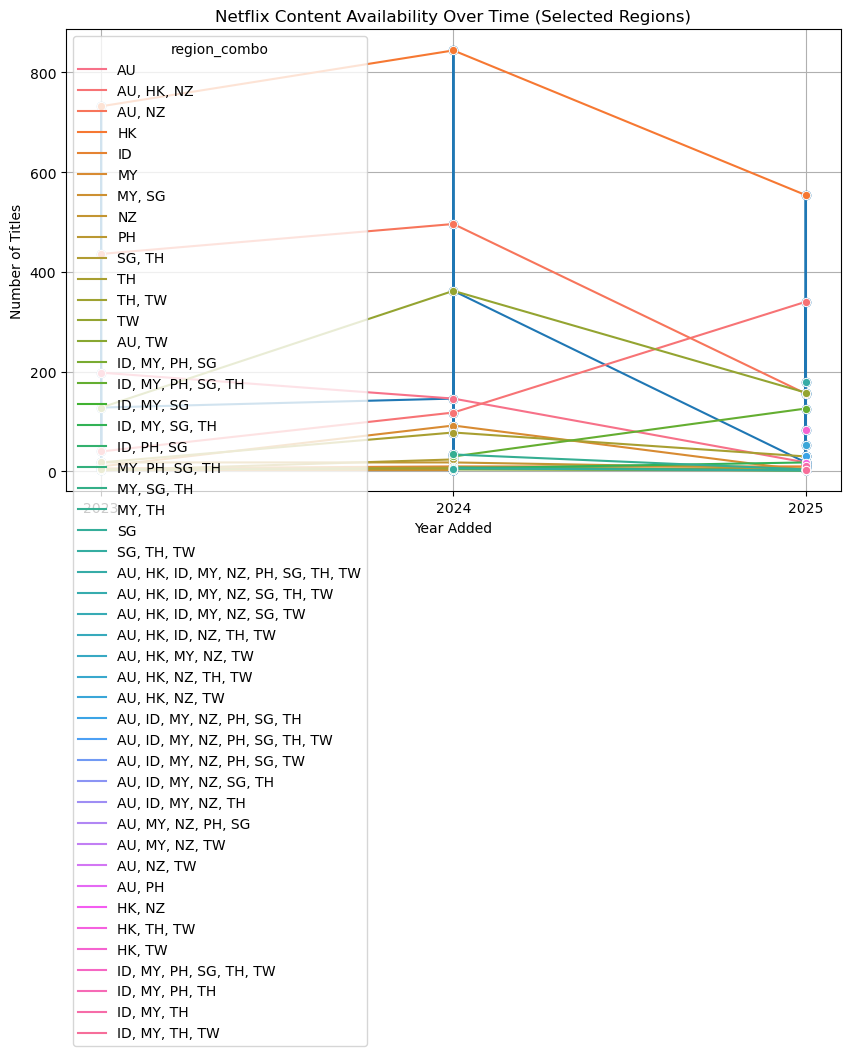

In [227]:
yearly = content_mix.groupby(["year_added","region_combo"])["count"].sum().reset_index()


fig, ax = plt.subplots(figsize=(10,6))

ax.plot(yearly["year_added"], yearly["count"], marker="o")

ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

sns.lineplot(
    data=yearly,
    x="year_added",
    y="count",
    hue="region_combo",
    marker="o"
)


plt.title("Netflix Content Availability Over Time (Selected Regions)")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()

In [228]:
df = content_mix.copy()
df["year_added"] = df["year_added"].astype(int)

df["num_regions"] = df["region_combo"].apply(lambda x: len(x.split(",")))
df["availability"] = df["num_regions"].apply(
    lambda x: "Single-region" if x == 1 else "Multi-region"
)

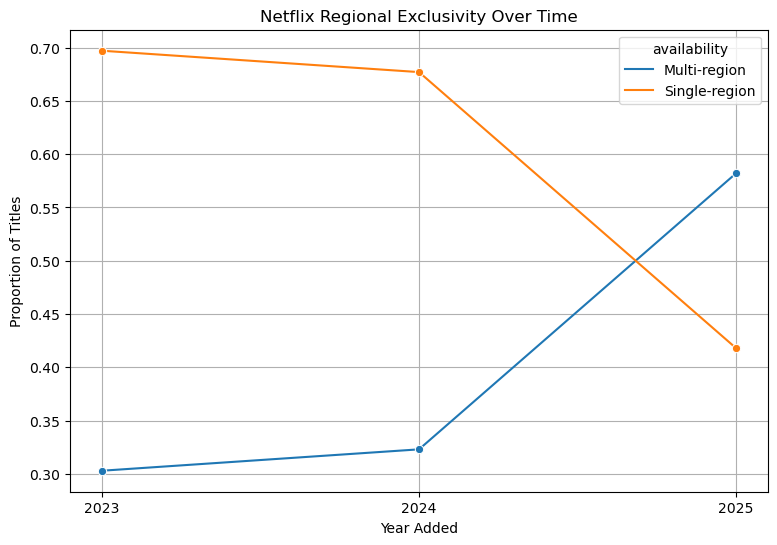

In [229]:
trend = (
    df.groupby(["year_added", "availability"])["proportion"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(9,6))
ax = sns.lineplot(
    data=trend,
    x="year_added",
    y="proportion",
    hue="availability",
    marker="o"
)

ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.title("Netflix Regional Exclusivity Over Time")
plt.xlabel("Year Added")
plt.ylabel("Proportion of Titles")
plt.grid(True)
plt.show()

# qns 1: How has Netflix’s regional distribution strategy evolved over time, regardless of content type?
## Findings:

Over time, Netflix content has become less regionally exclusive and more widely distributed across multiple Asia–Pacific markets. As seen from the graph, single-region titles are decreasing while multi-region titles are increasing. 

Hence it suggests that Netflix is moving away from highly localized content type while increasing cross-regional content sharing. This points to a regional consolidation strategy, where content is licensed or producted to serveral nearby markets rather than individual countries.

Multi-region growth implies things such as lower per marketing licensing cost, which align with a strategy produce once, distribute widely.

However this analysis pattern identity, catalog availability rather than audience demand. 

The observed decline in single-region titles alongside the growth of multi-region availability indicates a strategic shift in Netflix’s Asia–Pacific distribution approach. Rather than prioritizing country-specific licensing, Netflix appears to be increasingly favoring content that can be deployed across multiple regional markets, reflecting both cost efficiencies and the maturation of regional streaming ecosystems.

# Analysis to research qns #2 : Which genres appear most regionally distributed?



In [235]:
genre_df = df_dedup.explode("genres_list")

genre_df

,id,type,title,release_date,date_added_estimated,genres,popularity,vote_average,vote_count,regions,year_added,genres_list,region_combo
3,972445,Movie,CMXXIV,2025-12-31,2025-12-31,Comedy,2.6803,5.900,11,"[SG, MY, ID, PH, TH, AU, NZ, TW, HK]",2025,Comedy,"AU, HK, ID, MY, NZ, PH, SG, TH, TW"
4,1591516,Movie,Evil Influencer: The Jodi Hildebrandt Story,2025-12-30,2025-12-30,Documentary,14.4789,6.344,32,"[SG, MY, ID, PH, TH, AU, NZ, TW, HK]",2025,Documentary,"AU, HK, ID, MY, NZ, PH, SG, TH, TW"
5,1312150,Movie,Ricky Gervais: Mortality,2025-12-29,2025-12-29,Comedy,3.4495,6.840,50,"[SG, MY, ID, PH, TH, AU, NZ, TW, HK]",2025,Comedy,"AU, HK, ID, MY, NZ, PH, SG, TH, TW"
6,1603423,Movie,Mens Rea,2025-12-27,2025-12-27,Comedy,1.3887,7.300,5,"[SG, MY, ID, PH, TH, AU, NZ]",2025,Comedy,"AU, ID, MY, NZ, PH, SG, TH"
7,1605290,Movie,Snoop's Holiday Halftime Party,2025-12-25,2025-12-25,Music,0.1533,0.000,0,"[SG, MY, ID, PH, TH, AU, NZ, TW, HK]",2025,Music,"AU, HK, ID, MY, NZ, PH, SG, TH, TW"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5836,220158,TV Show,A Body That Works,2023-02-13,2023-02-13,Drama,1.0314,6.800,6,[NZ],2023,Drama,NZ
5837,209649,TV Show,Am I Actually the Strongest?,2023-07-02,2023-07-02,"Animation, Comedy, Action & Adventure, Sci-Fi ...",4.9105,7.400,92,[TW],2023,Animation,TW
5837,209649,TV Show,Am I Actually the Strongest?,2023-07-02,2023-07-02,"Animation, Comedy, Action & Adventure, Sci-Fi ...",4.9105,7.400,92,[TW],2023,Comedy,TW
5837,209649,TV Show,Am I Actually the Strongest?,2023-07-02,2023-07-02,"Animation, Comedy, Action & Adventure, Sci-Fi ...",4.9105,7.400,92,[TW],2023,Action & Adventure,TW


In [237]:

# Number of regions per row
genre_df["num_regions"] = genre_df["region_combo"].apply(lambda x: len(x.split(",")))



In [238]:
genre_distribution = (
    genre_df.groupby("genres_list")["num_regions"]
    .median()
    .sort_values(ascending=False)
)


In [240]:
genre_distribution

genres_list
Soap                  3.5
War & Politics        3.0
Western               2.0
Mystery               2.0
Talk                  2.0
Sci-Fi & Fantasy      2.0
Reality               2.0
Kids                  2.0
War                   1.0
Thriller              1.0
TV Movie              1.0
Science Fiction       1.0
Romance               1.0
Action                1.0
Action & Adventure    1.0
Horror                1.0
History               1.0
Fantasy               1.0
Family                1.0
Drama                 1.0
Documentary           1.0
Crime                 1.0
Comedy                1.0
Animation             1.0
Adventure             1.0
Music                 1.0
Name: num_regions, dtype: float64

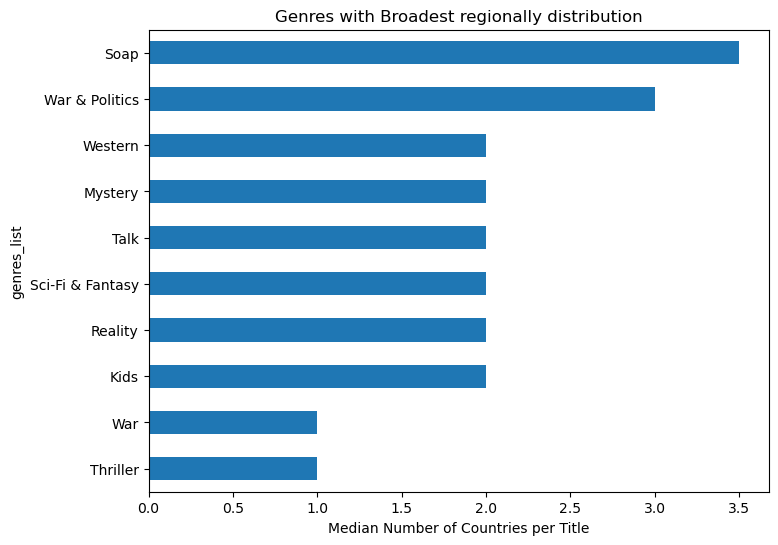

In [239]:
genre_distribution.head(10).plot(
    kind="barh", figsize=(8,6)
)
plt.title("Genres with Broadest regionally distribution")
plt.xlabel("Median Number of Countries per Title")
plt.gca().invert_yaxis()
plt.show()


# qns 2: Which genres appear most regionally distributed?
## Findings:
Regionally distribution is proxied by the number of countries associated with a title. 

Soap has a median of 3.5 regions while War and politics has a median of 3 regions, hence this genres appears in more countries per title than others, this suggests strong cross-cultural rsonance, content is offer designed for regional audiences. Why is make sense as Political and war narratives often address universal themes (power, conflict, history) while soap-style serialized content is designed for long-term engagement, these genres are often produced locally but distributed regionally.

Mid-tier genres with 2 regions coverage such as Mystery, sci-fi & fanstasy, reality, kids and talk shows travel across multiple but not all regions, likely face language barries, audience taste variation.

Lastly highly localised generes with median 1 region includes drama, comedy, romance, crime, documentary, horror, etc are heavily influenced by language , local humor, cultural norms, doesn't mean is not important only that they are localised by design.

However genres with the highest median regional coverage may reflect smaller sample sizes and should be interpreted with caution because i only used 50 pages limit for both movies and tv shows.

Analysis of regional distribution by genre reveals substantial variation in how widely individual titles are released across Asia–Pacific markets. Genres such as Soap and War & Politics exhibit the highest median regional coverage, suggesting strong cross-market scalability. In contrast, dominant genres such as Drama, Comedy, and Romance tend to be regionally concentrated, with most titles available in only one country. This pattern indicates that Netflix strategically combines regionally scalable genres with localized content production, balancing cost efficiency with market-specific audience engagement.

Netflix distributes globally scalable genres across multiple regions while maintaining strong localization in culturally specific genres.